# Section 2.3.2 — Filtres de convolution

Projet CNN — EFREI Paris (SM604).

Application manuelle (numpy pur) de 6 filtres de convolution à une image en niveaux de gris.
Aucune fonction boîte noire (pas de scipy/cv2/skimage).

## 1. Imports

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

## 2. Définition des 6 noyaux

In [2]:
K1 = (1.0 / 9.0) * np.array([[1, 1, 1],
                              [1, 1, 1],
                              [1, 1, 1]], dtype=float)              # Flou moyen

K2 = np.array([[0, -1, 0],
               [-1, 5, -1],
               [0, -1, 0]], dtype=float)                            # Netteté

K3 = np.array([[-1, 2, -1],
               [-1, 2, -1],
               [-1, 2, -1]], dtype=float)                           # Contours horizontaux

K4 = np.array([[-1, 0, 1],
               [-1, 0, 1],
               [-1, 0, 1]], dtype=float)                            # Contours verticaux (simple)

K5 = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=float)                            # Sobel vertical

K6 = np.array([[-2, -1, 0],
               [-1, 1, 1],
               [0, 1, 2]], dtype=float)                             # Contours diagonaux

NOYAUX = [
    ("K1 : Flou moyen",                K1),
    ("K2 : Netteté",                   K2),
    ("K3 : Contours horizontaux",      K3),
    ("K4 : Contours verticaux",        K4),
    ("K5 : Sobel vertical",            K5),
    ("K6 : Contours diagonaux",        K6),
]

## 3. Chargement de l'image

Deux fonctions disponibles :
- `charger_image_png` : pour un fichier .png/.jpg (utilise PIL).
- `charger_image_cifar` : pour une image issue d'un batch CIFAR-10.

In [3]:
def charger_image_png(chemin_png):
    """Charge un PNG/JPG en niveaux de gris (mode 'L'), retourne un array float [0, 255]."""
    img = Image.open(chemin_png).convert("L")
    return np.array(img, dtype=float)


CLASSES_CIFAR = ["airplane", "automobile", "bird", "cat", "deer",
                 "dog", "frog", "horse", "ship", "truck"]

def charger_image_cifar(chemin_batch, indice=None, classe=None, facteur_zoom=8):
    """Charge une image d'un batch CIFAR-10, en niveaux de gris (luminance BT.601).
    Si `classe` est fourni (ex. 'cat'), on prend la 1ère image de cette classe."""
    with open(chemin_batch, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    donnees = batch[b"data"]
    labels = batch[b"labels"]

    if classe is not None:
        cible = CLASSES_CIFAR.index(classe)
        indice = next(i for i, lab in enumerate(labels) if lab == cible)
        print(f"Classe '{classe}' (label {cible}) trouvée à l'indice {indice}")
    elif indice is None:
        indice = 0

    image_rgb = donnees[indice].reshape(3, 32, 32).transpose(1, 2, 0)
    image_gris = (0.299 * image_rgb[:, :, 0]
                  + 0.587 * image_rgb[:, :, 1]
                  + 0.114 * image_rgb[:, :, 2]).astype(float)
    if facteur_zoom > 1:
        image_gris = np.repeat(np.repeat(image_gris, facteur_zoom, axis=0),
                               facteur_zoom, axis=1)
    return image_gris

Dimensions de l'image : (778, 1036)


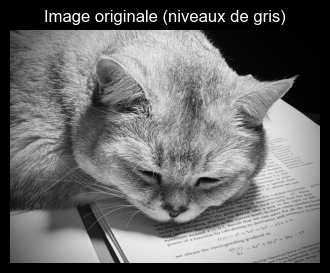

In [4]:
# === Choisir UNE source d'image en (dé)commentant ===
DOSSIER = os.getcwd()

# Option A — PNG fourni (chat)
image = charger_image_png(os.path.join(DOSSIER, "cifar-10-batches-py",
                                       "image chat projet.png"))

# Option B — image CIFAR-10 (1ère image de classe "cat" dans data_batch_1)
# image = charger_image_cifar(os.path.join(DOSSIER, "cifar-10-batches-py", "data_batch_1"),
#                             classe="cat")

print("Dimensions de l'image :", image.shape)
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Image originale (niveaux de gris)")
plt.axis("off")
plt.show()

## 4. Convolution 2D manuelle

Formule implémentée :
$$
m'[u, v] = \sum_{u'=1}^{3} \sum_{v'=1}^{3} K[u', v'] \cdot m[u'+u-2,\ v'+v-2] + l
$$
Zero-padding pour conserver les dimensions, clipping final dans $[0, 255]$.

In [5]:
def convolution_2d(image, noyau, biais=0.0):
    H, W = image.shape
    kH, kW = noyau.shape
    pad_h, pad_w = kH // 2, kW // 2

    # Zero-padding manuel
    image_pad = np.zeros((H + 2 * pad_h, W + 2 * pad_w), dtype=float)
    image_pad[pad_h:pad_h + H, pad_w:pad_w + W] = image

    # 9 itérations sur le noyau, vectorisé sur l'image
    sortie = np.zeros((H, W), dtype=float)
    for u_prime in range(kH):
        for v_prime in range(kW):
            coef = noyau[u_prime, v_prime]
            if coef == 0.0:
                continue
            sortie += coef * image_pad[u_prime:u_prime + H,
                                       v_prime:v_prime + W]
    sortie += biais
    return np.clip(sortie, 0.0, 255.0)

## 5. Application des 6 filtres et affichage

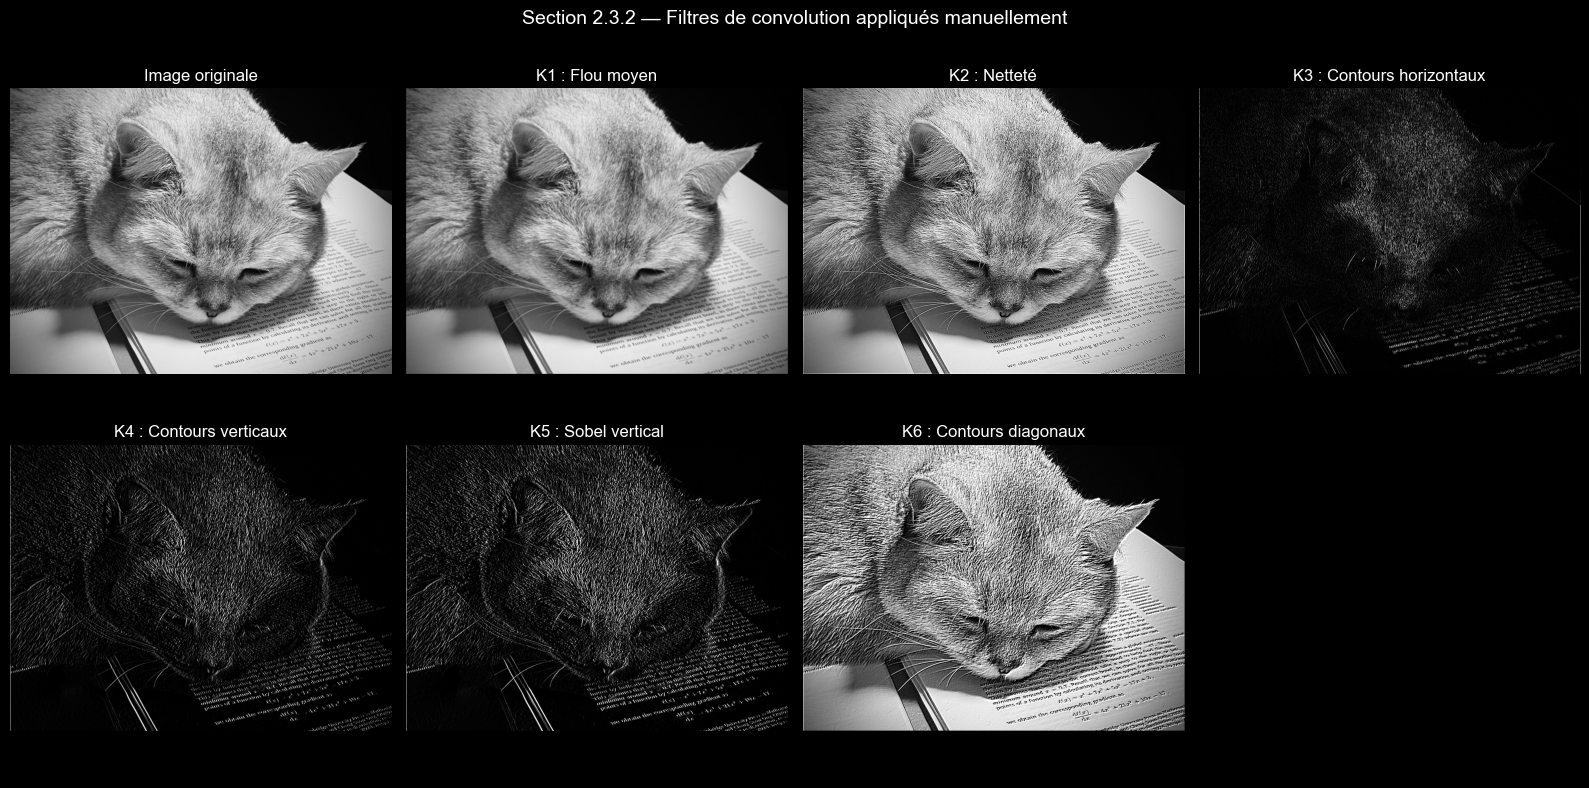

Figure sauvegardée : resultats_filtres.png


In [6]:
resultats = [(nom, convolution_2d(image, k, biais=0.0)) for nom, k in NOYAUX]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Image originale")
axes[0].axis("off")

for i, (nom, res) in enumerate(resultats, start=1):
    axes[i].imshow(res, cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(nom)
    axes[i].axis("off")

axes[7].axis("off")
fig.suptitle("Section 2.3.2 — Filtres de convolution appliqués manuellement", fontsize=14)
fig.tight_layout()
fig.savefig("resultats_filtres.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : resultats_filtres.png")